In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/pca_variables.csv")
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac", "extract_time", "named")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in stats_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

In [3]:
X = stats_df

In [4]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KDTree

lat_col = "lat"
lon_col = "lon"

# Features = numeric columns excluding lat/lon
feature_cols = (
    X.select_dtypes(include="number")
     .columns
     .difference([lat_col, lon_col])
     .tolist()
)

# Coordinates (must be finite)
X_filled = X.copy()
coords = X_filled[[lat_col, lon_col]].to_numpy()

if not np.isfinite(coords).all():
    raise ValueError("lat/lon contain NaN or inf; cannot do spatial interpolation.")

tree = KDTree(coords, metric="euclidean")
K_NEIGH = 5

n_rows = len(X_filled)

for col in feature_cols:
    vals = X_filled[col].to_numpy(dtype=float)
    nan_mask = np.isnan(vals)

    if not nan_mask.any():
        continue

    nan_pos = np.where(nan_mask)[0]  # positional indices of NaNs
    dist, idx = tree.query(coords[nan_pos], k=K_NEIGH)

    # Inverse-distance weights
    w = 1.0 / (dist + 1e-6)

    # Neighbor values
    neigh_vals = vals[idx]  # shape (n_nan, K_NEIGH)

    # Zero-out weights where neighbor is NaN
    valid = ~np.isnan(neigh_vals)
    w = w * valid

    wsum = w.sum(axis=1)
    # If some rows have all-NaN neighbors, fall back to column median
    fallback = np.nanmedian(vals)

    filled = np.empty(len(nan_pos), dtype=float)
    good = wsum > 0

    filled[good] = (w[good] * neigh_vals[good]).sum(axis=1) / wsum[good]
    filled[~good] = fallback

    # Assign back by POSITION to avoid index alignment issues
    X_filled.iloc[nan_pos, X_filled.columns.get_loc(col)] = filled

print("NaN counts after spatial interpolation:")
print(X_filled[feature_cols].isna().sum().sort_values(ascending=False).head(20))


NaN counts after spatial interpolation:
Unnamed: 0             0
magnitude              0
msl                    0
mwd                    0
mwp                    0
sp                     0
station                0
swh                    0
tau_v                  0
tp                     0
u10_abs                0
v10                    0
v10_abs                0
wind_dir               0
wind_wave_alignment    0
dtype: int64


In [5]:
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac", "name")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in X_filled.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X_filled = X_filled.drop(columns=[c for c in cols_to_drop if c in X_filled.columns])


In [6]:
X_filled

,wind_wave_alignment,tp,mwd,mwp,wind_dir,v10_abs,tau_v,msl,sp,v10,u10_abs,swh,extract_time,magnitude
0,-0.013936,0.001019,247.796335,5.997398,161.264250,3.109146,-0.016234,97898.440,97670.660,-3.109146,1.054550,1.801818,1952-09-30 12:00:00,3.278751
1,-0.013936,0.000237,247.796335,5.997398,60.971256,5.936523,0.600358,98755.310,98523.470,5.936523,10.697113,1.801818,1952-11-27 17:00:00,63.503662
2,-0.013936,0.000312,247.796335,5.997398,104.227630,2.741409,-0.129400,99196.750,98961.780,-2.741409,10.812012,1.801818,1952-12-13 00:00:00,29.640150
3,-0.013936,0.000000,247.796335,5.997398,253.570560,1.598282,-0.022050,101696.810,101457.300,-1.598282,5.420212,1.801818,1953-03-19 04:00:00,8.663026
4,-0.013936,0.000270,247.796335,5.997398,65.630450,5.498245,0.584350,100337.000,100099.940,5.498245,12.137955,1.801818,1953-04-05 15:00:00,66.737460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51007,0.780636,0.000260,248.036290,5.611906,52.582420,7.269272,0.799587,100835.060,100498.945,7.269272,9.501770,2.041333,2024-04-09 05:00:00,69.070946
51008,-0.877431,0.000303,254.571440,4.100668,76.000970,2.591583,0.111182,100241.060,99915.560,2.591583,10.395020,1.086706,2024-07-06 05:00:00,26.939560
51009,-0.519277,0.001815,284.221920,5.812461,106.175930,2.624329,-0.099227,100914.190,100586.530,-2.624329,9.047180,1.661644,2024-09-10 23:00:00,23.742773
51010,0.161320,0.000745,248.048070,4.479193,58.143745,2.281738,0.030445,100158.690,99828.970,2.281738,3.672012,0.665076,2024-11-25 07:00:00,8.378571


Best K by silhouette (sampled): 2


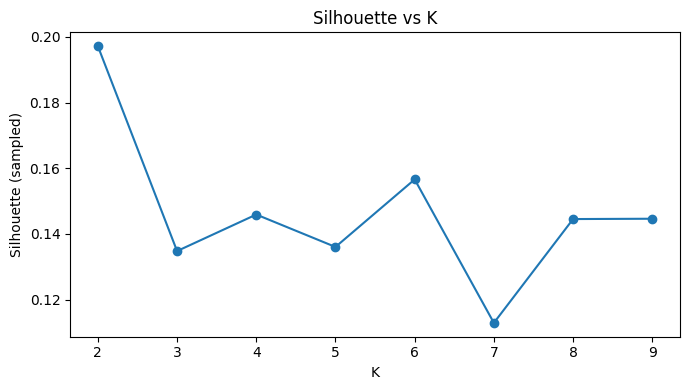

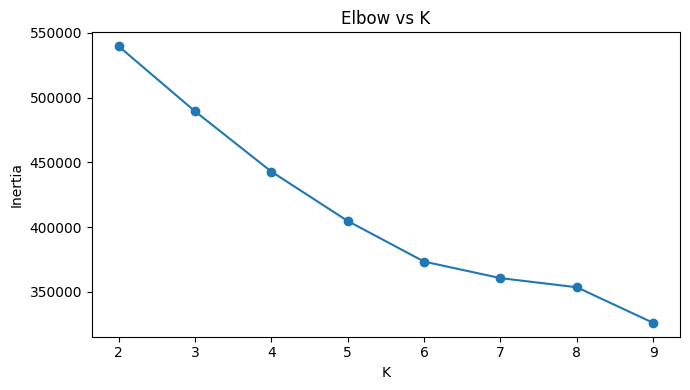

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xc = X_filled.select_dtypes(include="number").copy()
Xc = Xc.replace([np.inf, -np.inf], np.nan)

if Xc.isna().any().any():
    Xc = Xc.fillna(Xc.median(numeric_only=True))

Xs = StandardScaler().fit_transform(Xc.to_numpy(dtype=float))

K_RANGE = range(2, 10)

sil_scores, inertias = [], []
models = {}

# silhouette sampling (tune this)
SAMPLE_SIZE = min(50000, Xs.shape[0])
RANDOM_STATE = 0

from sklearn.cluster import MiniBatchKMeans

for K in K_RANGE:
    km = MiniBatchKMeans(
        n_clusters=K,
        random_state=RANDOM_STATE,
        batch_size=2048,
        n_init=10,
        max_no_improvement=10,
    )
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)

    sil = silhouette_score(
        Xs,
        labels,
        metric="euclidean",
        sample_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
    )
    sil_scores.append(sil)

    models[K] = (km, labels)

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
print("Best K by silhouette (sampled):", best_k)

# plots
plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), sil_scores, marker="o")
plt.xticks(list(K_RANGE))
plt.xlabel("K")
plt.ylabel("Silhouette (sampled)")
plt.title("Silhouette vs K")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), inertias, marker="o")
plt.xticks(list(K_RANGE))
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow vs K")
plt.tight_layout()
plt.show()


In [ ]:
best_k = 8

# attach labels for best K
stats_df= stats_df.copy()
stats_df["cluster"] = models[best_k][1]
km, labels = models[best_k]

: 

: 

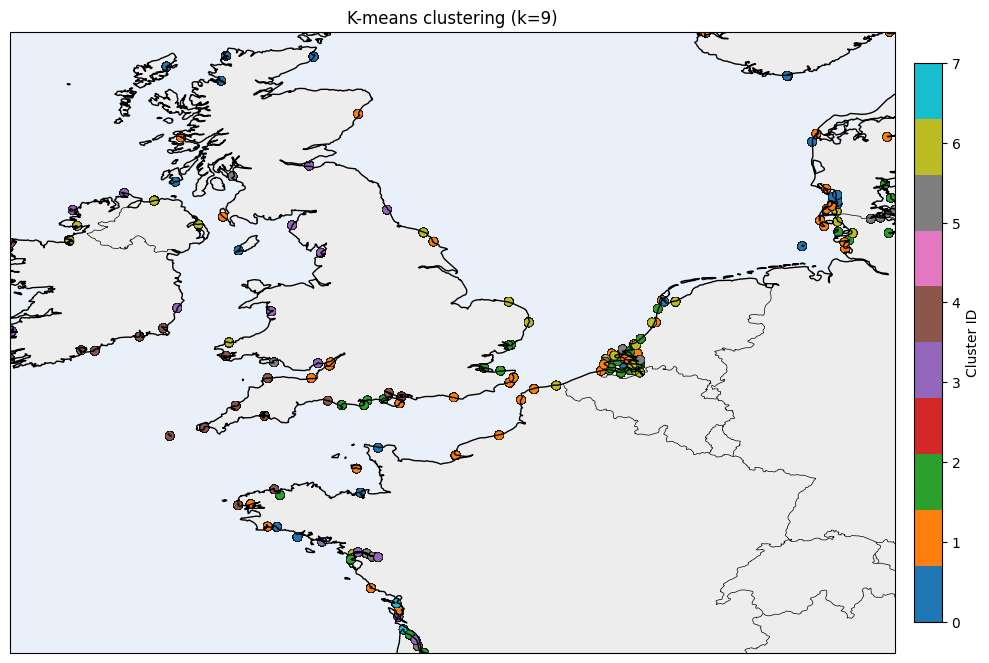

: 

In [ ]:
lat = stats_df["lat"]
lon = stats_df["lon"]
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.coastlines(linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, alpha=0.2)

sc = ax.scatter(
    lon,
    lat,
    c=labels,
    cmap="tab10",
    s=40,
    edgecolor="k",
    linewidth=0.3,
    transform=ccrs.PlateCarree(),
)

cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("Cluster ID")

ax.set_title(f"K-means clustering (k={K})")
ax.set_extent([lon.min(), lon.max(), lat.min(),lat.max(), ])

plt.tight_layout()
plt.show()


In [ ]:
stats_df.to_csv("weather_fit.csv")

: 